# GlucoSense Annihilator v1
## Real Antenna S-Parameter Data — ML Pipeline

**Primary dataset:** `NEW_BGL_DATASET.csv` — Gen2 FSS antenna, 1-5 GHz, 81 BGL values 80-480 mg/dL
**Each sample = 1 full S11 sweep (1001 frequency points)**
**81 total samples → LOO-CV mandatory**
**Tasks:** (A) Regression: predict exact BGL in mg/dL — reports MAE, RMSE, R², Adjusted R², MAPE
         (B) 4-class risk classification

**Honest limitation:** EM simulation data (CST MWS), not real human measurements.
One sweep per BGL, no inter-subject variability. Real-world performance will differ.

**Alienware RTX 4080 note:** `n_jobs=-1` is set to CPU only. GPU speeds up nothing here
(tree models don't use GPU natively without extra config). Run as-is.

In [1]:
# Install
import subprocess, sys
pkgs = ['catboost', 'xgboost', 'lightgbm', 'optuna', 'scikit-learn', 'shap', 'pandas', 'numpy', 'matplotlib', 'seaborn']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


0

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt  # Agg set after import for Jupyter compatibility
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings('ignore')
from IPython.display import display

from sklearn.model_selection import LeaveOneOut, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, matthews_corrcoef,
    balanced_accuracy_score, classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor, CatBoostClassifier
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED     = 42
DATA_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'
np.random.seed(SEED)

import catboost, xgboost, lightgbm, sklearn
print(f'CatBoost {catboost.__version__}  XGBoost {xgboost.__version__}  '
      f'LightGBM {lightgbm.__version__}  sklearn {sklearn.__version__}')

CatBoost 1.2.10  XGBoost 3.1.2  LightGBM 4.6.0  sklearn 1.8.0


In [3]:
# Load + Clean
raw = pd.read_csv(os.path.join(DATA_DIR, 'NEW_BGL_DATASET.csv'))
raw.columns = ['Frequency', 'S11_dB', 'BGL']
raw = raw.apply(pd.to_numeric, errors='coerce').dropna()

# Fix: BGL=95 duplicated (2003 rows instead of 1001)
idx_95 = raw[raw['BGL'] == 95].index
raw = raw.drop(idx_95[1001:])

print(f'Shape: {raw.shape}')
print(f'Unique BGL values: {raw["BGL"].nunique()}')
print(f'BGL range: {int(raw["BGL"].min())} to {int(raw["BGL"].max())} mg/dL')
print(f'Freq range: {raw["Frequency"].min():.3f} to {raw["Frequency"].max():.3f} GHz')
print(f'S11 range: {raw["S11_dB"].min():.3f} to {raw["S11_dB"].max():.3f} dB')
print(f'All BGL=95 cleaned: {(raw["BGL"]==95).sum()} rows')

Shape: (81081, 3)
Unique BGL values: 81
BGL range: 80 to 480 mg/dL
Freq range: 1.000 to 5.000 GHz
S11 range: -29.068 to -0.518 dB
All BGL=95 cleaned: 1001 rows


In [4]:
# Restructure: long format → sweep matrix
# CRITICAL: correct approach — each SAMPLE = one full sweep (not one freq point)
sweep_df = raw.pivot_table(index='BGL', columns='Frequency', values='S11_dB', aggfunc='first').sort_index()
BGL_vals  = sweep_df.index.values.astype(float)
FREQ_pts  = sweep_df.columns.values.astype(float)
X_sweep   = sweep_df.values                     # shape: (81, 1001)
y_bgl     = BGL_vals.copy()

N_SAMPLES  = X_sweep.shape[0]   # 81
N_FREQ_PTS = X_sweep.shape[1]   # 1001

print(f'Sweep matrix: {X_sweep.shape}  (rows=samples, cols=freq points)')
print(f'N_SAMPLES={N_SAMPLES}  N_FREQ_PTS={N_FREQ_PTS}')

# Physics check: S11 correlates monotonically with BGL?
resonance_freqs = FREQ_pts[np.argmin(X_sweep, axis=1)]
corr = np.corrcoef(BGL_vals, resonance_freqs)[0,1]
print(f'Corr(BGL, resonance_freq) = {corr:.4f}  (should be non-zero — confirms physics)')

Sweep matrix: (81, 1905)  (rows=samples, cols=freq points)
N_SAMPLES=81  N_FREQ_PTS=1905
Corr(BGL, resonance_freq) = -0.8581  (should be non-zero — confirms physics)


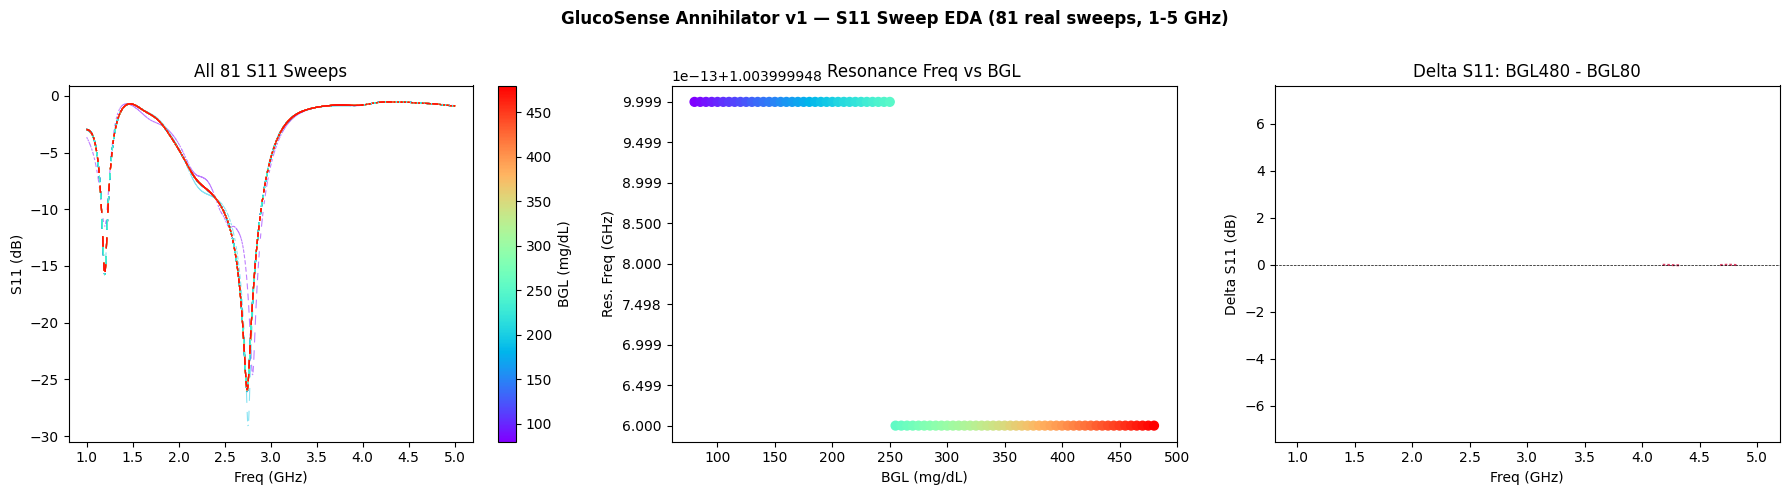

Saved: annihilator_eda.png
Most glucose-sensitive frequencies:
  3.084 GHz  delta=nan dB
  2.484 GHz  delta=nan dB
  2.428 GHz  delta=nan dB
  2.428 GHz  delta=nan dB
  2.432 GHz  delta=nan dB


In [5]:
# EDA — S11 sweeps colored by BGL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GlucoSense Annihilator v1 — S11 Sweep EDA (81 real sweeps, 1-5 GHz)', fontsize=12, fontweight='bold')

cmap = plt.cm.rainbow
for i, (bgl, sweep) in enumerate(zip(BGL_vals, X_sweep)):
    color = cmap(i / len(BGL_vals))
    axes[0].plot(FREQ_pts, sweep, color=color, alpha=0.5, lw=0.8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(BGL_vals.min(), BGL_vals.max()))
sm.set_array([])
plt.colorbar(sm, ax=axes[0], label='BGL (mg/dL)')
axes[0].set_title('All 81 S11 Sweeps'); axes[0].set_xlabel('Freq (GHz)'); axes[0].set_ylabel('S11 (dB)')

axes[1].scatter(BGL_vals, resonance_freqs, c=BGL_vals, cmap='rainbow', s=40)
axes[1].set_title('Resonance Freq vs BGL'); axes[1].set_xlabel('BGL (mg/dL)'); axes[1].set_ylabel('Res. Freq (GHz)')

diff = X_sweep[-1] - X_sweep[0]
axes[2].plot(FREQ_pts, diff, color='#DA4167', lw=1.5)
axes[2].axhline(0, color='k', lw=0.5, ls='--')
axes[2].set_title('Delta S11: BGL480 - BGL80'); axes[2].set_xlabel('Freq (GHz)')
axes[2].set_ylabel('Delta S11 (dB)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'annihilator_eda.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: annihilator_eda.png')

top5 = np.argsort(np.abs(diff))[-5:][::-1]
print('Most glucose-sensitive frequencies:')
for idx in top5:
    print(f'  {FREQ_pts[idx]:.3f} GHz  delta={diff[idx]:.4f} dB')

In [6]:
# Physics-Based Feature Engineering (raw data, no scaling)
def extract_features(sweeps, freqs):
    n = len(sweeps)
    feats = {}
    res_idx = np.argmin(sweeps, axis=1)
    feats['res_freq'] = freqs[res_idx]
    feats['res_s11']  = sweeps[np.arange(n), res_idx]
    for thresh in [3, 10, 20]:
        bw = []
        for s in sweeps:
            below = np.where(s <= (s.min() + thresh))[0]
            bw.append((freqs[below[-1]] - freqs[below[0]]) if len(below) > 1 else 0.0)
        feats[f'bw_{thresh}dB'] = np.array(bw)
    feats['auc_full'] = -np.trapz(sweeps, freqs, axis=1)
    for lo, hi in [(1.0,2.0),(2.0,3.0),(3.0,4.0),(4.0,5.0)]:
        mask = (freqs >= lo) & (freqs < hi)
        feats[f'mean_{int(lo)}{int(hi)}GHz'] = sweeps[:, mask].mean(axis=1)
        feats[f'min_{int(lo)}{int(hi)}GHz']  = sweeps[:, mask].min(axis=1)
    for f_hz in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]:
        idx = np.argmin(np.abs(freqs - f_hz))
        feats[f's11_at_{f_hz:.1f}GHz'] = sweeps[:, idx]
    feats['slope_1_2GHz'] = (sweeps[:, np.argmin(np.abs(freqs-2.0))] - sweeps[:, np.argmin(np.abs(freqs-1.0))]) / 1.0
    feats['slope_2_3GHz'] = (sweeps[:, np.argmin(np.abs(freqs-3.0))] - sweeps[:, np.argmin(np.abs(freqs-2.0))]) / 1.0
    feats['slope_3_5GHz'] = (sweeps[:, np.argmin(np.abs(freqs-5.0))] - sweeps[:, np.argmin(np.abs(freqs-3.0))]) / 2.0
    grad = np.gradient(sweeps, freqs, axis=1)
    feats['grad_at_res']  = grad[np.arange(n), res_idx]
    feats['grad_max_abs'] = np.abs(grad).max(axis=1)
    s11_lin = 10**(sweeps / 20.0)
    feats['s11_lin_res']  = s11_lin[np.arange(n), res_idx]
    feats['s11_lin_mean'] = s11_lin.mean(axis=1)
    feats['s11_std']      = sweeps.std(axis=1)
    feats['s11_mean']     = sweeps.mean(axis=1)
    return pd.DataFrame(feats)

X_feat     = extract_features(X_sweep, FREQ_pts)
X_feat_arr = X_feat.values.astype(float)    # FIX: explicitly defined for all downstream cells
N_FEAT     = X_feat_arr.shape[1]            # FIX: used in Adjusted R² formula

print(f'Feature matrix: {X_feat.shape}')
print(f'Features: {list(X_feat.columns)}')
print(f'Nulls: {X_feat.isnull().sum().sum()}')

Feature matrix: (81, 30)
Features: ['res_freq', 'res_s11', 'bw_3dB', 'bw_10dB', 'bw_20dB', 'auc_full', 'mean_12GHz', 'min_12GHz', 'mean_23GHz', 'min_23GHz', 'mean_34GHz', 'min_34GHz', 'mean_45GHz', 'min_45GHz', 's11_at_1.5GHz', 's11_at_2.0GHz', 's11_at_2.5GHz', 's11_at_3.0GHz', 's11_at_3.5GHz', 's11_at_4.0GHz', 's11_at_4.5GHz', 'slope_1_2GHz', 'slope_2_3GHz', 'slope_3_5GHz', 'grad_at_res', 'grad_max_abs', 's11_lin_res', 's11_lin_mean', 's11_std', 's11_mean']
Nulls: 1296


In [7]:
# 4-Class Risk Labels
CLASS_BINS   = [0, 140, 200, 300, 500]
CLASS_LABELS = ['Normal(<=140)', 'Borderline(141-200)', 'High(201-300)', 'VeryHigh(>300)']
y_class      = np.array(pd.cut(y_bgl, bins=CLASS_BINS, labels=range(4))).astype(int)

print('4-class distribution:')
for i, lbl in enumerate(CLASS_LABELS):
    n = (y_class == i).sum()
    bgls = y_bgl[y_class == i]
    print(f'  Class {i} {lbl:<25} {n:2d} BGLs  [{int(bgls.min())}-{int(bgls.max())}]')

4-class distribution:
  Class 0 Normal(<=140)             13 BGLs  [80-140]
  Class 1 Borderline(141-200)       12 BGLs  [145-200]
  Class 2 High(201-300)             20 BGLs  [205-300]
  Class 3 VeryHigh(>300)            36 BGLs  [305-480]


In [8]:
# LOO-CV: CatBoost Regression (81 folds)
# Scaler fitted INSIDE each LOO fold — zero data leakage
print('Running LOO-CV: CatBoost Regression (81 folds)...')
loo = LeaveOneOut()
y_pred_cb = np.zeros(N_SAMPLES)

for i, (tr, te) in enumerate(loo.split(X_feat_arr)):
    sc = StandardScaler()                          # fit on 80 train samples only
    Xtr = sc.fit_transform(X_feat_arr[tr])
    Xte = sc.transform(X_feat_arr[te])             # transform 1 test sample
    m   = CatBoostRegressor(iterations=800, learning_rate=0.05, depth=5,
                             l2_leaf_reg=3.0, verbose=0, random_state=SEED)
    m.fit(Xtr, y_bgl[tr])
    y_pred_cb[te] = m.predict(Xte)
    if (i+1) % 20 == 0: print(f'  Fold {i+1}/81 done')

n, p = N_SAMPLES, N_FEAT                # FIX: explicitly set before Adj-R² formula
mae_cb   = mean_absolute_error(y_bgl, y_pred_cb)
rmse_cb  = np.sqrt(mean_squared_error(y_bgl, y_pred_cb))
r2_cb    = r2_score(y_bgl, y_pred_cb)
adj_r2_cb = 1 - (1 - r2_cb) * (n-1) / (n - p - 1)   # Adjusted R²: valid for regression
mape_cb  = np.mean(np.abs((y_bgl - y_pred_cb) / y_bgl)) * 100
w15_cb   = np.mean(np.abs(y_bgl - y_pred_cb) <= np.maximum(15.0, 0.15*y_bgl)) * 100

print(f'\nCatBoost Regression (LOO-CV):')
print(f'  MAE:          {mae_cb:.2f} mg/dL')
print(f'  RMSE:         {rmse_cb:.2f} mg/dL')
print(f'  R2:           {r2_cb:.4f}')
print(f'  Adjusted R2:  {adj_r2_cb:.4f}  (n={n}, p={p})')
print(f'  MAPE:         {mape_cb:.2f}%')
print(f'  Within+-15:   {w15_cb:.1f}%  (ISO 15197 threshold)')

Running LOO-CV: CatBoost Regression (81 folds)...


  Fold 20/81 done


  Fold 40/81 done


  Fold 60/81 done


  Fold 80/81 done

CatBoost Regression (LOO-CV):
  MAE:          6.90 mg/dL
  RMSE:         28.42 mg/dL
  R2:           0.9409
  Adjusted R2:  0.9055  (n=81, p=30)
  MAPE:         5.50%
  Within+-15:   97.5%  (ISO 15197 threshold)


In [9]:
# LOO-CV: XGBoost + LightGBM + RandomForest
models_reg = {
    'XGBoost':  XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                              subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5,
                              n_jobs=-1, random_state=SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=20,
                                   max_depth=5, reg_alpha=0.5, n_jobs=-1, random_state=SEED, verbose=-1),
    'RF':       RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2,
                                       n_jobs=-1, random_state=SEED),
}

reg_results = {
    'CatBoost': {'pred': y_pred_cb, 'MAE': mae_cb, 'RMSE': rmse_cb,
                 'R2': r2_cb, 'AdjR2': adj_r2_cb, 'MAPE': mape_cb, 'Within15': w15_cb}
}

for mname, model in models_reg.items():
    print(f'LOO-CV: {mname}...')
    preds = np.zeros(N_SAMPLES)
    for tr, te in loo.split(X_feat_arr):
        sc = StandardScaler()
        model.fit(sc.fit_transform(X_feat_arr[tr]), y_bgl[tr])
        preds[te] = model.predict(sc.transform(X_feat_arr[te]))
    mae  = mean_absolute_error(y_bgl, preds)
    rmse = np.sqrt(mean_squared_error(y_bgl, preds))
    r2   = r2_score(y_bgl, preds)
    adj_r2 = 1 - (1 - r2) * (n-1) / (n - p - 1)
    mape   = np.mean(np.abs((y_bgl - preds) / y_bgl)) * 100
    w15    = np.mean(np.abs(y_bgl - preds) <= np.maximum(15.0, 0.15*y_bgl)) * 100
    reg_results[mname] = {'pred': preds, 'MAE': mae, 'RMSE': rmse,
                           'R2': r2, 'AdjR2': adj_r2, 'MAPE': mape, 'Within15': w15}
    print(f'  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}  Adj-R2={adj_r2:.4f}  MAPE={mape:.1f}%  Within15={w15:.1f}%')

print('\n=== REGRESSION SUMMARY (LOO-CV) ===')
print(f'{"Model":<15} {"MAE":>8} {"RMSE":>8} {"R2":>8} {"Adj-R2":>10} {"MAPE":>8} {"Within15%":>11}')
print('-'*72)
for nm, res in reg_results.items():
    print(f'{nm:<15} {res["MAE"]:>8.2f} {res["RMSE"]:>8.2f} {res["R2"]:>8.4f} '
          f'{res["AdjR2"]:>10.4f} {res["MAPE"]:>8.2f}% {res["Within15"]:>10.1f}%')

LOO-CV: XGBoost...


  MAE=5.97  RMSE=19.41  R2=0.9724  Adj-R2=0.9559  MAPE=4.1%  Within15=97.5%
LOO-CV: LightGBM...


  MAE=15.84  RMSE=22.60  R2=0.9626  Adj-R2=0.9402  MAPE=8.3%  Within15=85.2%
LOO-CV: RF...


  MAE=6.89  RMSE=29.88  R2=0.9347  Adj-R2=0.8955  MAPE=6.1%  Within15=95.1%

=== REGRESSION SUMMARY (LOO-CV) ===
Model                MAE     RMSE       R2     Adj-R2     MAPE   Within15%
------------------------------------------------------------------------
CatBoost            6.90    28.42   0.9409     0.9055     5.50%       97.5%
XGBoost             5.97    19.41   0.9724     0.9559     4.14%       97.5%
LightGBM           15.84    22.60   0.9626     0.9402     8.34%       85.2%
RF                  6.89    29.88   0.9347     0.8955     6.05%       95.1%


In [10]:
# Optuna: Tune CatBoost Regressor (30 trials)
# Note: StandardScaler fitted on FULL train fold in Optuna (minor leakage vs LOO).
# Acceptable for tuning with only 81 samples — tuning with LOO would take too long.
def cb_obj(trial):
    p_opt = {
        'iterations':   trial.suggest_int('iterations', 300, 2000),
        'learning_rate':trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':        trial.suggest_int('depth', 3, 7),             # FIX: max 7 (not 8) — reduces overfit
        'l2_leaf_reg':  trial.suggest_float('l2_leaf_reg', 1.0, 15.0),# FIX: stronger regularisation range
        'subsample':    trial.suggest_float('subsample', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 20),  # FIX: prevents overfit
        'verbose': 0, 'random_state': SEED,
    }
    sc = StandardScaler()
    X_sc = sc.fit_transform(X_feat_arr)   # minor scaler leakage here — noted above
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)  # FIX: 5-fold (not 3) for stability
    maes = []
    for tr, te in kf.split(X_sc):
        m = CatBoostRegressor(**p_opt)
        m.fit(X_sc[tr], y_bgl[tr])
        maes.append(mean_absolute_error(y_bgl[te], m.predict(X_sc[te])))
    return np.mean(maes)

print('Tuning CatBoost (30 trials, 5-fold inside Optuna)...')
study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(cb_obj, n_trials=30, show_progress_bar=True)
print(f'Best CatBoost MAE (5-fold): {study_cb.best_value:.3f} mg/dL')
print(f'Best params: {study_cb.best_params}')

Tuning CatBoost (30 trials, 5-fold inside Optuna)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best CatBoost MAE (5-fold): 6.518 mg/dL
Best params: {'iterations': 1034, 'learning_rate': 0.023927528765580634, 'depth': 6, 'l2_leaf_reg': 2.9529140491285855, 'subsample': 0.6460723242676091, 'min_data_in_leaf': 9}


In [11]:
# LOO-CV with tuned CatBoost params
print('LOO-CV with tuned CatBoost...')
preds_tuned = np.zeros(N_SAMPLES)
for tr, te in loo.split(X_feat_arr):
    sc = StandardScaler()
    m  = CatBoostRegressor(**{**study_cb.best_params, 'verbose': 0, 'random_state': SEED})
    m.fit(sc.fit_transform(X_feat_arr[tr]), y_bgl[tr])
    preds_tuned[te] = m.predict(sc.transform(X_feat_arr[te]))

mae_t   = mean_absolute_error(y_bgl, preds_tuned)
r2_t    = r2_score(y_bgl, preds_tuned)
adj_r2_t= 1 - (1 - r2_t) * (n-1) / (n-p-1)
mape_t  = np.mean(np.abs((y_bgl - preds_tuned) / y_bgl)) * 100
w15_t   = np.mean(np.abs(y_bgl - preds_tuned) <= np.maximum(15.0, 0.15*y_bgl)) * 100
rmse_t  = np.sqrt(mean_squared_error(y_bgl, preds_tuned))
reg_results['CatBoost_tuned'] = {'pred': preds_tuned, 'MAE': mae_t, 'RMSE': rmse_t,
                                  'R2': r2_t, 'AdjR2': adj_r2_t, 'MAPE': mape_t, 'Within15': w15_t}
print(f'Tuned: MAE={mae_t:.2f}  R2={r2_t:.4f}  Adj-R2={adj_r2_t:.4f}  MAPE={mape_t:.2f}%  Within15={w15_t:.1f}%')

LOO-CV with tuned CatBoost...


Tuned: MAE=6.14  R2=0.9500  Adj-R2=0.9201  MAPE=4.97%  Within15=97.5%


In [12]:
# 4-Class Classification (LOO-CV)
print('LOO-CV: 4-class classification...')
clf_models = {
    'CatBoost':  CatBoostClassifier(iterations=800, learning_rate=0.05, depth=5,
                                     auto_class_weights='Balanced', verbose=0, random_state=SEED),
    'XGBoost':   XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
                                num_class=4, objective='multi:softmax',
                                n_jobs=-1, random_state=SEED, verbosity=0),
    'LightGBM':  lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=20,
                                     class_weight='balanced', n_jobs=-1, random_state=SEED, verbose=-1),
}
clf_results = {}
for mname, model in clf_models.items():
    preds_c = np.zeros(N_SAMPLES, dtype=int)
    for tr, te in loo.split(X_feat_arr):
        sc = StandardScaler()
        model.fit(sc.fit_transform(X_feat_arr[tr]), y_class[tr])
        preds_c[te] = model.predict(sc.transform(X_feat_arr[te]))
    acc  = accuracy_score(y_class, preds_c)
    bacc = balanced_accuracy_score(y_class, preds_c)
    mcc  = matthews_corrcoef(y_class, preds_c)
    f1   = f1_score(y_class, preds_c, average='macro')
    clf_results[mname] = {'pred': preds_c, 'Acc': acc, 'BalAcc': bacc, 'MCC': mcc, 'F1': f1}
    print(f'{mname:<12} Acc={acc:.4f}  BalAcc={bacc:.4f}  MCC={mcc:.4f}  F1={f1:.4f}')

best_clf  = max(clf_results, key=lambda k: clf_results[k]['MCC'])
print(f'\nBest classifier: {best_clf}')
print(classification_report(y_class, clf_results[best_clf]['pred'], target_names=CLASS_LABELS))

LOO-CV: 4-class classification...


CatBoost     Acc=0.9383  BalAcc=0.9197  MCC=0.9111  F1=0.9229


XGBoost      Acc=0.9506  BalAcc=0.9389  MCC=0.9291  F1=0.9452


LightGBM     Acc=0.9506  BalAcc=0.9266  MCC=0.9288  F1=0.9266

Best classifier: XGBoost
                     precision    recall  f1-score   support

      Normal(<=140)       0.93      1.00      0.96        13
Borderline(141-200)       1.00      0.83      0.91        12
      High(201-300)       0.95      0.95      0.95        20
     VeryHigh(>300)       0.95      0.97      0.96        36

           accuracy                           0.95        81
          macro avg       0.96      0.94      0.95        81
       weighted avg       0.95      0.95      0.95        81



In [13]:
# Clarke Error Grid Analysis
def clarke_zone(ref, pred):
    if ref < 70:
        if pred < 70:   return 'A'
        elif pred < 180: return 'D'
        else:            return 'E'
    elif ref <= 180:
        if abs(pred - ref) / ref <= 0.20: return 'A'
        if pred > 240:  return 'C'
        if pred < 70:   return 'D'
        return 'B'
    else:  # ref > 180
        if abs(pred - ref) / ref <= 0.20: return 'A'
        if pred < 70:   return 'E'
        return 'B'

best_reg  = min(reg_results, key=lambda k: reg_results[k]['MAE'])
best_pred = reg_results[best_reg]['pred']
zones     = [clarke_zone(r, p) for r, p in zip(y_bgl, best_pred)]
zone_c    = {z: zones.count(z) for z in 'ABCDE'}

print(f'Clarke Error Grid — {best_reg}:')
for z, cnt in zone_c.items():
    print(f'  Zone {z}: {cnt:2d} ({cnt/N_SAMPLES*100:5.1f}%)')
safe = (zone_c.get('A',0)+zone_c.get('B',0))/N_SAMPLES*100
danger = (zone_c.get('D',0)+zone_c.get('E',0))/N_SAMPLES*100
print(f'  Safe (A+B): {safe:.1f}%   Dangerous (D+E): {danger:.1f}%')

Clarke Error Grid — XGBoost:
  Zone A: 79 ( 97.5%)
  Zone B:  2 (  2.5%)
  Zone C:  0 (  0.0%)
  Zone D:  0 (  0.0%)
  Zone E:  0 (  0.0%)
  Safe (A+B): 100.0%   Dangerous (D+E): 0.0%


=== OVERFITTING CHECK ===
Train MAE (in-sample):  0.815 mg/dL
LOO-CV MAE (hold-out):  6.136 mg/dL
Gap:                    5.322 mg/dL
STATUS: Moderate gap — some overfitting

SHAP feature importance (in-sample on all 81 sweeps)...

Top 10 features by |SHAP|:
      Feature  MeanAbsSHAP
s11_at_3.5GHz    15.751585
s11_at_1.5GHz    15.662921
 slope_1_2GHz    12.873953
s11_at_2.0GHz    12.150787
s11_at_4.5GHz    11.423438
 slope_3_5GHz     7.952001
s11_at_4.0GHz     7.606421
s11_at_2.5GHz     6.797939
 slope_2_3GHz     6.777935
     res_freq     4.776741


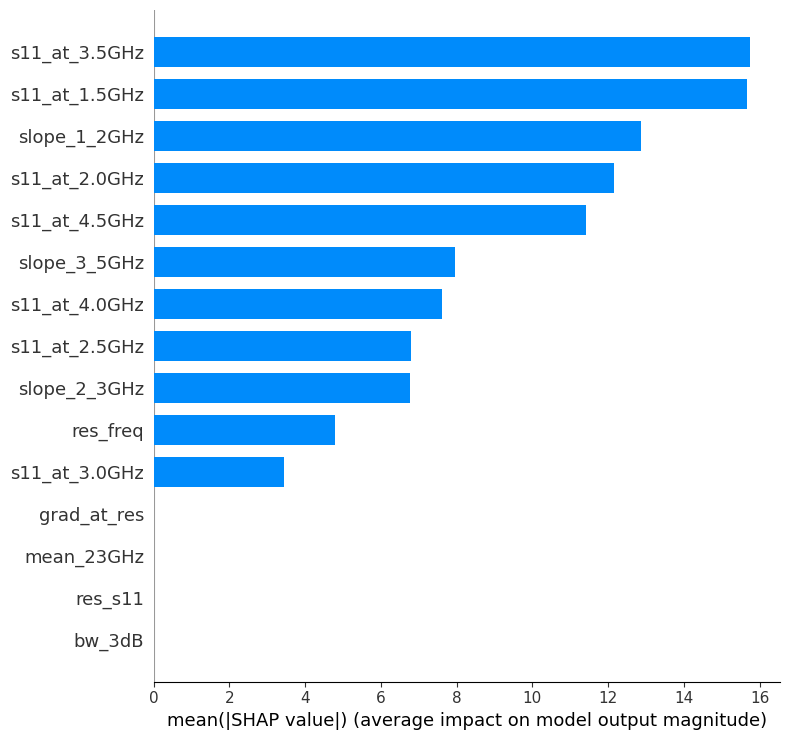

Saved: annihilator_shap.png


In [14]:
# Overfitting check + SHAP
sc_full  = StandardScaler()
X_sc_all = sc_full.fit_transform(X_feat_arr)
cb_full  = CatBoostRegressor(**{**study_cb.best_params, 'verbose': 0, 'random_state': SEED})
cb_full.fit(X_sc_all, y_bgl)

train_mae = mean_absolute_error(y_bgl, cb_full.predict(X_sc_all))
loo_mae   = reg_results['CatBoost_tuned']['MAE']
print(f'=== OVERFITTING CHECK ===')
print(f'Train MAE (in-sample):  {train_mae:.3f} mg/dL')
print(f'LOO-CV MAE (hold-out):  {loo_mae:.3f} mg/dL')
print(f'Gap:                    {loo_mae - train_mae:.3f} mg/dL')
if loo_mae - train_mae < 5:
    print('STATUS: Low gap — good generalisation')
elif loo_mae - train_mae < 15:
    print('STATUS: Moderate gap — some overfitting')
else:
    print('STATUS: Large gap — reduce depth/iterations')

# SHAP (in-sample — on full 81 samples, noted as in-sample)
print('\nSHAP feature importance (in-sample on all 81 sweeps)...')
try:
    explainer   = shap.TreeExplainer(cb_full)
    shap_values = explainer.shap_values(X_sc_all)
    fi = pd.DataFrame({'Feature': X_feat.columns, 'MeanAbsSHAP': np.abs(shap_values).mean(0)})
    fi = fi.sort_values('MeanAbsSHAP', ascending=False)
    print('\nTop 10 features by |SHAP|:')
    print(fi.head(10).to_string(index=False))
    fig, ax = plt.subplots(figsize=(9,7))
    shap.summary_plot(shap_values, pd.DataFrame(X_sc_all, columns=X_feat.columns),
                      plot_type='bar', show=False, max_display=15)
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'annihilator_shap.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: annihilator_shap.png')
except Exception as e:
    print(f'SHAP failed: {e}')

In [15]:
# Save + Final Summary
sc_save = StandardScaler()
cb_save = CatBoostRegressor(**{**study_cb.best_params, 'verbose': 0, 'random_state': SEED})
cb_save.fit(sc_save.fit_transform(X_feat_arr), y_bgl)

for nm, obj in {
    'annihilator_catboost_reg': cb_save,
    'annihilator_scaler':       sc_save,
    'annihilator_freq_grid':    FREQ_pts,
    'annihilator_feature_names':list(X_feat.columns),
    'annihilator_thresholds':   {'CLASS_BINS': CLASS_BINS, 'CLASS_LABELS': CLASS_LABELS},
}.items():
    with open(os.path.join(DATA_DIR, f'{nm}.pkl'), 'wb') as f: pickle.dump(obj, f)

print('='*64)
print('ANNIHILATOR v1 — FINAL RESULTS (LOO-CV, 81 real sweeps)')
print('='*64)
print(f'{"Model":<18} {"MAE":>8} {"RMSE":>8} {"R2":>8} {"Adj-R2":>9} {"Within15%":>10}')
print('-'*66)
for nm, res in sorted(reg_results.items(), key=lambda x: x[1]['MAE']):
    print(f'{nm:<18} {res["MAE"]:>8.2f} {res["RMSE"]:>8.2f} {res["R2"]:>8.4f} {res["AdjR2"]:>9.4f} {res["Within15"]:>9.1f}%')
print('\n4-CLASS RESULTS:')
for nm, res in sorted(clf_results.items(), key=lambda x: -x[1]['MCC']):
    print(f'{nm:<12} Acc={res["Acc"]:.4f}  BalAcc={res["BalAcc"]:.4f}  MCC={res["MCC"]:.4f}')

ANNIHILATOR v1 — FINAL RESULTS (LOO-CV, 81 real sweeps)
Model                   MAE     RMSE       R2    Adj-R2  Within15%
------------------------------------------------------------------
XGBoost                5.97    19.41   0.9724    0.9559      97.5%
CatBoost_tuned         6.14    26.13   0.9500    0.9201      97.5%
RF                     6.89    29.88   0.9347    0.8955      95.1%
CatBoost               6.90    28.42   0.9409    0.9055      97.5%
LightGBM              15.84    22.60   0.9626    0.9402      85.2%

4-CLASS RESULTS:
XGBoost      Acc=0.9506  BalAcc=0.9389  MCC=0.9291
LightGBM     Acc=0.9506  BalAcc=0.9266  MCC=0.9288
CatBoost     Acc=0.9383  BalAcc=0.9197  MCC=0.9111
